In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
iris = load_iris()
x = iris.data
y = iris.target
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2, random_state=42)
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_test)
print(f'Before - mean: {x_train[:,0].mean():.2f}, std: {x_train[:,0].std():.2f}')
print(f'After - mean: {x_train_s[:,0].mean():.2f}, std: {x_train_s[:,0].std():.2f}')

Before - mean: 5.81, std: 0.82
After - mean: 0.00, std: 1.00


In [ ]:
from sklearn.linear_model import LogisticRegression
# (assume x_train_s, x_test_s, y_train, y_test are already defined)

lr = LogisticRegression(max_iter = 200, random_state = 42)
lr.fit(x_train_s, y_train)
preds = lr.predict(x_test_s)
print('Predicted : ',preds[:10])
print('Actual: ',y_test[:10])

Predicted :  [1 0 2 1 1 0 1 2 1 1]
Actual:  [1 0 2 1 1 0 1 2 1 1]


In [ ]:
from sklearn.metrics import accuracy_score , classification_report
from sklearn.datasets import load_iris
iris = load_iris()
acc = accuracy_score(y_test,preds)
print(f'Accuracy: {acc:.2f}')
print(classification_report(y_test,preds,target_names=iris.target_names))

Accuracy: 1.00
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


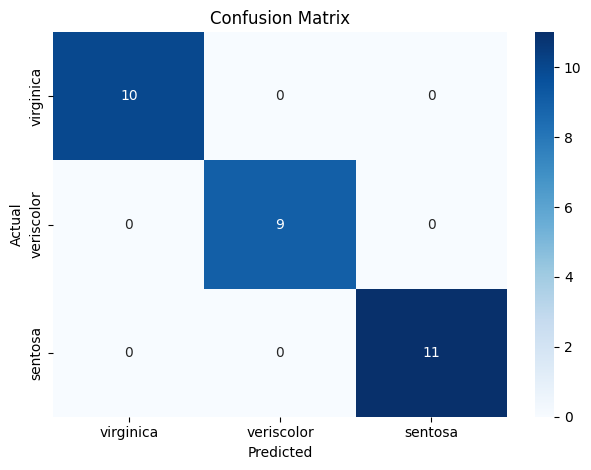

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
class_names = {'sentosa','veriscolor','virginica'}
cm = confusion_matrix(y_test,preds)
print(cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('sklearn_cm.png', dpi=100); plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

for k in [1, 5, 15] :
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(x_train_s, y_train)
    acc = accuracy_score(y_test, knn.predict(x_test_s))
    print(f'KNN (k={k}) Accuracy: {acc:.2f}')

KNN (k=1) Accuracy: 1.00
KNN (k=5) Accuracy: 1.00
KNN (k=15) Accuracy: 1.00


In [ ]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np
iris = load_iris()
dt = DecisionTreeClassifier(max_depth = 3, random_state = 42)
dt.fit(x_train_s, y_train)
print(f'Accuracy: {accuracy_score(y_test, dt.predict(x_test_s)):.2f}')
importances = dt.feature_importances_
idx = np.argsort(importances)[::-1]
for i in idx:
    print(f'{iris.feature_names[i]:25s}:{importances[i]:.4f}')

Accuracy: 0.97
petal length (cm)        :0.5911
petal width (cm)         :0.4089
sepal width (cm)         :0.0000
sepal length (cm)        :0.0000


In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

housing = fetch_california_housing()
x, y = housing.data, housing.target
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
lr = LinearRegression()
lr.fit(x_train, y_train)
preds = lr.predict(x_test)
print(f'MSE : {mean_squared_error(y_test, preds):.2f}')
print(f'R2 : {r2_score(y_test,preds):.2f}')

MSE : 0.56
R2 : 0.58
